# KMeans++ Initialization

This notebook demonstrates how K-Means++ selects initial cluster centers before the standard K-Means optimization begins.

A synthetic two-dimensional dataset containing four Gaussian clusters is generated. The `kmeans_plusplus()` function selects four observations as the initial centers. These centers are then supplied directly to a K-Means model.

The notebook performs the following operations:
- Defines the project folders and experiment settings.
- Generates and summarizes a synthetic dataset.
- Examines the true cluster distribution.
- Selects initial centers using K-Means++.
- Measures distances between the selected centers.
- Fits K-Means using the selected initial centers.
- Calculates clustering evaluation metrics.
- Compares the initial and final cluster centers.
- Creates and saves essential visualizations.
- Saves result tables and a complete run summary.

All plots are saved in:
```
root_folder/plots/kmeanspp_init/
```
All result files are saved in:
```
root_folder/results/kmeanspp_init/
```

### Import Required Libraries

This section imports the libraries required for folder management, dataset generation, K-Means++ initialization, clustering, evaluation, visualization, and result storage.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display

from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.metrics.pairwise import euclidean_distances

##### Explanation :
The required libraries are now available.
- `Path` manages the project folders.
- `perf_counter` measures model-fitting time.
- `NumPy` performs numerical calculations.
- `Pandas` creates and saves result tables.
- `Matplotlib` creates the visualizations.
- `make_blobs` generates the synthetic dataset.
- `kmeans_plusplus` selects the initial cluster centers.
- `KMeans` performs the final clustering.
- The metric functions evaluate the clustering result.

No output is expected from this cell.

### Define the Project Folders

The notebook is expected to be located inside the notebooks folder. This section automatically identifies the root project folder and creates the required output folders when they do not already exist.

Expected notebook location:
```
root_folder/notebooks/05_kmeanspp_init.ipynb
```
Output folders:
```
root_folder/plots/kmeanspp_init/
root_folder/results/kmeanspp_init/
```

In [2]:
def find_project_root(start_path):
    """
    Find the main project folder containing:
    data/, notebooks/, plots/, and results/.
    """
    current_path = Path(start_path).resolve()

    # Check the current folder and all parent folders
    for folder in [current_path, *current_path.parents]:
        required_folders = [
            folder / "data",
            folder / "notebooks",
            folder / "plots",
            folder / "results",
        ]

        if all(required_folder.is_dir() for required_folder in required_folders):
            return folder

    raise FileNotFoundError(
        "The project root could not be found. "
        "Make sure the project contains data, notebooks, plots, and results folders."
    )


# Folder from which Jupyter is currently running
CURRENT_DIR = Path.cwd().resolve()

# Find the main project folder
ROOT_DIR = find_project_root(CURRENT_DIR)

# Notebook folder and notebook file
NOTEBOOK_DIR = ROOT_DIR / "notebooks" / "module_2"
NOTEBOOK_PATH = NOTEBOOK_DIR / "04_kmeanspp_init.ipynb"

# Output folders for this notebook
PLOTS_DIR = ROOT_DIR / "plots" / "kmeanspp_init"
RESULTS_DIR = ROOT_DIR / "results" / "kmeanspp_init"

# Create output folders if they do not already exist
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Display the detected project paths
print("=" * 100)
print("PROJECT FOLDERS")
print("=" * 100)
print(f"Current folder  : {CURRENT_DIR}")
print(f"Root folder     : {ROOT_DIR}")
print(f"Notebook folder : {NOTEBOOK_DIR}")
print(f"Notebook file   : {NOTEBOOK_PATH}")
print(f"Plots folder    : {PLOTS_DIR}")
print(f"Results folder  : {RESULTS_DIR}")
print("=" * 100)

# Check whether the paths exist
print("\nPATH CHECK")
print("-" * 100)
print(f"Root folder exists     : {ROOT_DIR.exists()}")
print(f"Notebook folder exists : {NOTEBOOK_DIR.exists()}")
print(f"Notebook file exists   : {NOTEBOOK_PATH.exists()}")
print(f"Plots folder exists    : {PLOTS_DIR.exists()}")
print(f"Results folder exists  : {RESULTS_DIR.exists()}")

PROJECT FOLDERS
Current folder  : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Root folder     : C:\Users\samsa\Documents\Capstone Project\Project
Notebook folder : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2
Notebook file   : C:\Users\samsa\Documents\Capstone Project\Project\notebooks\module_2\04_kmeanspp_init.ipynb
Plots folder    : C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeanspp_init
Results folder  : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init

PATH CHECK
----------------------------------------------------------------------------------------------------
Root folder exists     : True
Notebook folder exists : True
Notebook file exists   : True
Plots folder exists    : True
Results folder exists  : True


##### Explanation :
The output confirms that the notebook correctly identified the project structure.

When the notebook is executed from the notebooks folder:

- `ROOT_DIR` points to `root_folder`.
- `PLOTS_DIR` points to `root_folder/plots/kmeanspp_init`.
- `RESULTS_DIR` points to `root_folder/results/kmeanspp_init`.

The folders are created automatically if they are missing. Existing folders are not deleted or overwritten.

### Define the Experiment Settings

This section defines the settings used throughout the notebook.

The experiment uses:

- $4,000$ observations
- $4$ Gaussian clusters
- $2$ numerical features
- Cluster standard deviation of $0.60$
- Random seed of $0$
- Four K-Means++ initial centers

The fixed random seed makes the dataset generation and initialization reproducible.

In [3]:
# Reproducibility
RANDOM_STATE = 0

# Synthetic dataset settings
N_SAMPLES = 4_000
N_CLUSTERS = 4
CLUSTER_STD = 0.60

# Plot-saving quality
FIGURE_DPI = 300

# Colors used to represent the four clusters
CLUSTER_COLORS = [
    "#4EACC5",
    "#FF9C34",
    "#4E9A06",
    "m",
]

print("=" * 80)
print("EXPERIMENT SETTINGS")
print("=" * 80)
print(f"Number of samples : {N_SAMPLES:,}")
print(f"Number of clusters: {N_CLUSTERS}")
print(f"Cluster deviation : {CLUSTER_STD}")
print(f"Random seed       : {RANDOM_STATE}")
print("=" * 80)

EXPERIMENT SETTINGS
Number of samples : 4,000
Number of clusters: 4
Cluster deviation : 0.6
Random seed       : 0


##### Explanation 

The output displays the main experiment settings.

A cluster standard deviation of 0.60 creates relatively compact and well-separated groups. This dataset therefore represents a situation in which K-Means is expected to perform well.

The random seed ensures that repeated executions normally generate the same dataset and select the same initial observations.

### Create a Function for Saving Figures

This helper function saves every Matplotlib figure as a high-resolution PNG file inside the K-Means++ plot folder.

Using one function keeps the figure-saving process consistent throughout the notebook.

In [4]:
def save_figure(fig, filename):
    """
    Save a Matplotlib figure in the K-Means++ plots folder.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure that will be saved.

    filename : str
        Name of the PNG file.

    Returns
    -------
    pathlib.Path
        Complete path of the saved figure.
    """
    output_path = PLOTS_DIR / filename

    fig.savefig(
        output_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight",
    )

    print(f"Figure saved to:\n{output_path}")

    return output_path

##### Explanation :
The function is now available for all later plots.

Every figure will be:

- Saved inside `plots/kmeanspp_init`
- Stored at $300$ dots per inch
- Cropped using bbox_inches="tight" to reduce unnecessary whitespace

No output is expected until the function is called.

### Generate the Synthetic Dataset

The `make_blobs()` function creates four compact Gaussian clusters.

This type of dataset is suitable for demonstrating K-Means because the clusters are:

- Approximately spherical
- Similar in size
- Relatively compact
- Clearly separated

The two feature columns are reversed to match the orientation used in the original scikit-learn K-Means++ example.

In [5]:
X, y_true = make_blobs(
    n_samples=N_SAMPLES,
    centers=N_CLUSTERS,
    cluster_std=CLUSTER_STD,
    random_state=RANDOM_STATE,
)

# Reverse the order of the feature columns
X = X[:, ::-1]

print("=" * 80)
print("GENERATED DATASET")
print("=" * 80)
print(f"Feature matrix shape : {X.shape}")
print(f"Label vector shape   : {y_true.shape}")
print(f"Observed labels      : {np.unique(y_true)}")
print("=" * 80)

GENERATED DATASET
Feature matrix shape : (4000, 2)
Label vector shape   : (4000,)
Observed labels      : [0 1 2 3]


##### Explanation :
The generated feature matrix has the following shape:

$$
(4000, 2)
$$

This means that the dataset contains:

- $4,000$ observations
- $2$ numerical features

The true label vector has 4,000 entries, and the observed synthetic labels are:
$$
[0, 1, 2, 3]
$$
These true labels are available because the data were generated synthetically. In a real unsupervised clustering problem, the true cluster labels would usually not be available.

### Create and Save the Dataset Summary

This section calculates a descriptive summary of the generated dataset.

The summary includes:

- Number of observations
- Number of features
- Number of true clusters
- Feature means
- Feature standard deviations
- Feature minimum values
- Feature maximum values

The table is saved as `data_summary.csv`.

In [6]:
dataset_summary_df = pd.DataFrame(
    {
        "Metric": [
            "Number of samples",
            "Number of features",
            "Number of true clusters",
            "Feature 1 mean",
            "Feature 1 standard deviation",
            "Feature 1 minimum",
            "Feature 1 maximum",
            "Feature 2 mean",
            "Feature 2 standard deviation",
            "Feature 2 minimum",
            "Feature 2 maximum",
        ],
        "Value": [
            X.shape[0],
            X.shape[1],
            np.unique(y_true).size,
            X[:, 0].mean(),
            X[:, 0].std(),
            X[:, 0].min(),
            X[:, 0].max(),
            X[:, 1].mean(),
            X[:, 1].std(),
            X[:, 1].min(),
            X[:, 1].max(),
        ],
    }
)

# Convert the values to numeric form and round them
dataset_summary_df["Value"] = pd.to_numeric(
    dataset_summary_df["Value"],
    errors="coerce",
).round(4)

display(dataset_summary_df)

# Save the summary
dataset_summary_path = RESULTS_DIR / "data_summary.csv"

dataset_summary_df.to_csv(
    dataset_summary_path,
    index=False,
)

print(f"Dataset summary saved to:\n{dataset_summary_path}")

,Metric,Value
0,Number of samples,4000.0000
1,Number of features,2.0000
2,Number of true clusters,4.0000
3,Feature 1 mean,3.9825
4,Feature 1 standard deviation,2.5884
5,Feature 1 minimum,-1.1377
6,Feature 1 maximum,9.6373
7,Feature 2 mean,0.0528
8,Feature 2 standard deviation,1.6009
9,Feature 2 minimum,-3.1240


Dataset summary saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init\data_summary.csv


##### Explanation :
The summary provides a numerical description of the generated feature space.

In the original notebook execution:
- Feature 1 had a mean of approximately `3.9825`
- Feature 1 had a standard deviation of approximately `2.5884`
- Feature 2 had a mean of approximately `0.0528`
- Feature 2 had a standard deviation of approximately `1.6009`

The wider spread of Feature 1 indicates that the cluster centers are distributed more broadly along the horizontal direction than along the vertical direction.

The complete summary is saved as:
```
results/kmeanspp_init/data_summary.csv
```

### Examine the True Cluster Sizes

Because the dataset is synthetic, the original cluster labels are known.

This section counts the observations in each true cluster and calculates the percentage of the complete dataset represented by each group.

The result is saved as `true_sizes.csv`

In [7]:
true_cluster_sizes_df = (
    pd.Series(y_true, name="True_cluster")
    .value_counts()
    .sort_index()
    .rename_axis("True_cluster")
    .reset_index(name="Sample_count")
)

true_cluster_sizes_df["Percentage"] = (
    true_cluster_sizes_df["Sample_count"]
    / len(y_true)
    * 100
).round(2)

display(true_cluster_sizes_df)

# Save the true cluster sizes
true_cluster_sizes_path = RESULTS_DIR / "true_sizes.csv"

true_cluster_sizes_df.to_csv(
    true_cluster_sizes_path,
    index=False,
)

print(f"True cluster sizes saved to:\n{true_cluster_sizes_path}")

,True_cluster,Sample_count,Percentage
0,0,1000,25.0
1,1,1000,25.0
2,2,1000,25.0
3,3,1000,25.0


True cluster sizes saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init\true_sizes.csv


##### Explanation :
Each of the four generated clusters contains $1000$ observations.

Therefore, every cluster represents exactly $25\%$ of the dataset.

This balanced distribution is useful for the tutorial because differences in clustering quality are not caused by severe class imbalance.

The result is saved as:
```
results/kmeanspp_init/true_sizes.csv
```

### Visualize the Generated Gaussian Clusters

This plot displays the four original synthetic groups before K-Means++ initialization or K-Means fitting.

Each color represents one true synthetic cluster.

The plot is saved as `data_blobs.png`.

Figure saved to:
C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeanspp_init\data_blobs.png


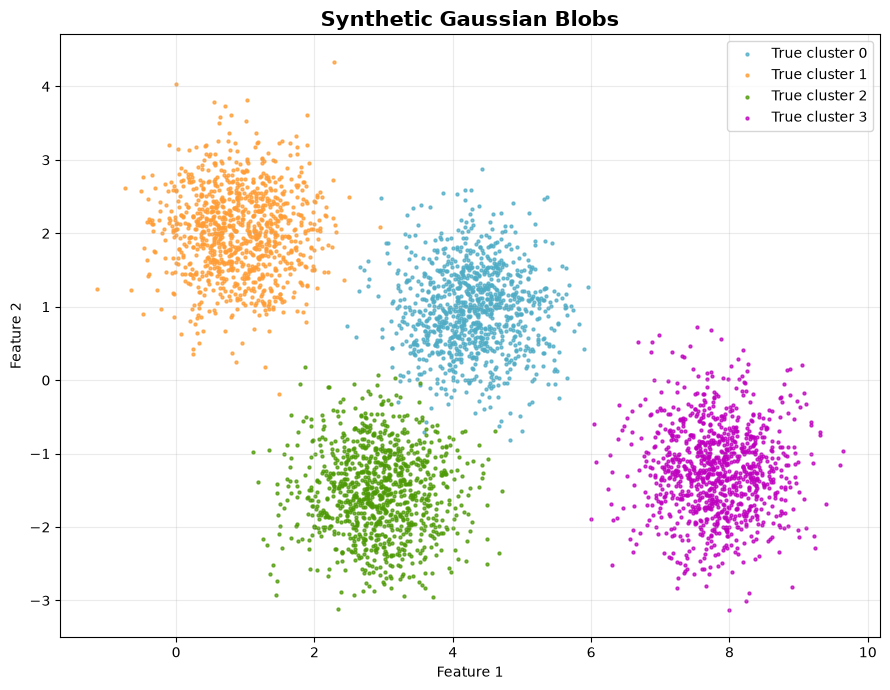

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

for cluster_id, color in enumerate(CLUSTER_COLORS):
    cluster_mask = y_true == cluster_id

    ax.scatter(
        X[cluster_mask, 0],
        X[cluster_mask, 1],
        color=color,
        marker=".",
        s=18,
        alpha=0.75,
        label=f"True cluster {cluster_id}",
    )

ax.set_title(
    "Synthetic Gaussian Blobs",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

save_figure(fig, "data_blobs.png")

plt.show()

##### Explanation :
The plot should show four compact groups in different regions of the feature space.

The visual separation suggests that:

The observations within each group are relatively close together.
The distances between the major groups are comparatively large.
A four-cluster K-Means model should be able to recover the underlying structure accurately.

The plot is saved as:
```
plots/kmeanspp_init/data_blobs.png
```

### Select the Initial Centers with K-Means++

K-Means++ selects initial centers that are distributed across different regions of the dataset.

The function returns:

- `centers_init`: coordinates of the selected initial centers
- `selected_indices`: row positions of the selected observations

The selected centers are actual observations from the dataset.

In [9]:
centers_init, selected_indices = kmeans_plusplus(
    X,
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
)

print("=" * 80)
print("K-MEANS++ INITIALIZATION")
print("=" * 80)

print("Selected row indices:")
print(selected_indices)

print("\nSelected center coordinates:")
print(centers_init)

print("=" * 80)

K-MEANS++ INITIALIZATION
Selected row indices:
[2195 2161 1757 1589]

Selected center coordinates:
[[ 0.87697863  1.49527778]
 [ 7.6941952  -1.27299937]
 [ 4.0410953   0.28778889]
 [ 2.81112585 -1.71731334]]


##### Explanation :
Using the specified random seed, the original notebook selected observations at the following row positions:
```
[2195, 2161, 1757, 1589]
```
The four observations are located in different parts of the feature space.

K-Means++ does not immediately calculate the final cluster means. It only selects suitable starting points. Standard K-Means optimization is performed later.

Minor differences may occur across scikit-learn versions, but the same random seed should normally provide reproducible initialization.

### Save the Selected Initial Centers

This section creates a table containing:

- Seed number
- Selected dataset row
- Feature 1 coordinate
- Feature 2 coordinate
- Original synthetic cluster of the selected observation

The result is saved as `init_centers.csv`.

In [10]:
initial_centers_df = pd.DataFrame(
    {
        "Seed": np.arange(1, N_CLUSTERS + 1),
        "Sample_index": selected_indices,
        "Feature_1": centers_init[:, 0],
        "Feature_2": centers_init[:, 1],
        "True_cluster": y_true[selected_indices],
    }
)

# Create a rounded version for display
initial_centers_display = initial_centers_df.copy()

initial_centers_display[["Feature_1", "Feature_2"]] = (
    initial_centers_display[["Feature_1", "Feature_2"]]
    .round(4)
)

display(initial_centers_display)

# Save the complete unrounded values
initial_centers_path = RESULTS_DIR / "init_centers.csv"

initial_centers_df.to_csv(
    initial_centers_path,
    index=False,
)

print(f"Initial centers saved to:\n{initial_centers_path}")

,Seed,Sample_index,Feature_1,Feature_2,True_cluster
0,1,2195,0.8770,1.4953,1
1,2,2161,7.6942,-1.2730,3
2,3,1757,4.0411,0.2878,0
3,4,1589,2.8111,-1.7173,2


Initial centers saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init\init_centers.csv


##### Explanation :
The table shows that K-Means++ selected one observation from each of the four true synthetic clusters.

This is an effective initialization because every major data region is represented by one starting center.

The rounded values are displayed in the notebook, while the complete numerical values are saved as:
```
results/kmeanspp_init/init_centers.csv
```

### Calculate Distances Between the Initial Centers

A useful initialization should distribute centers across different regions of the feature space.

This section calculates the Euclidean distance between every pair of selected centers.

The diagonal values are zero because the distance from a center to itself is zero.

The matrix is saved as `seed_distances.csv`.

In [11]:
initial_distance_matrix = euclidean_distances(
    centers_init,
    centers_init,
)

seed_labels = [
    f"Seed {seed_number}"
    for seed_number in range(1, N_CLUSTERS + 1)
]

initial_distance_df = pd.DataFrame(
    initial_distance_matrix,
    index=seed_labels,
    columns=seed_labels,
)

display(initial_distance_df.round(4))

# Save the complete distance matrix
initial_distance_path = RESULTS_DIR / "seed_distances.csv"

initial_distance_df.to_csv(
    initial_distance_path,
    index=True,
)

# Extract the unique nonzero distances
upper_triangle = initial_distance_matrix[
    np.triu_indices(N_CLUSTERS, k=1)
]

print("=" * 80)
print("INITIAL-CENTER DISTANCE SUMMARY")
print("=" * 80)
print(f"Minimum distance: {upper_triangle.min():.4f}")
print(f"Mean distance   : {upper_triangle.mean():.4f}")
print(f"Maximum distance: {upper_triangle.max():.4f}")
print("=" * 80)

print(f"Distance matrix saved to:\n{initial_distance_path}")

,Seed 1,Seed 2,Seed 3,Seed 4
Seed 1,0.0000,7.3578,3.3867,3.7499
Seed 2,7.3578,0.0000,3.9726,4.9032
Seed 3,3.3867,3.9726,0.0000,2.3523
Seed 4,3.7499,4.9032,2.3523,0.0000


INITIAL-CENTER DISTANCE SUMMARY
Minimum distance: 2.3523
Mean distance   : 4.2871
Maximum distance: 7.3578
Distance matrix saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init\seed_distances.csv


##### Explanation :
The original notebook produced approximately:

- Minimum seed distance: `2.3523`
- Mean seed distance: `4.2871`
- Maximum seed distance: `7.3578`

These values indicate that the selected centers are not concentrated within one small region.

The minimum distance is still large enough to show that even the two nearest initial centers represent meaningfully different parts of the dataset.

The distance matrix is saved as:
```
results/kmeanspp_init/seed_distances.csv
```

### Visualize the Initial-Center Distance Matrix

This heatmap provides a visual representation of the pairwise distances between the K-Means++ initial centers.

Larger values indicate that two centers are farther apart.

The plot is saved as `seed_distances.png`.

Figure saved to:
C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeanspp_init\seed_distances.png


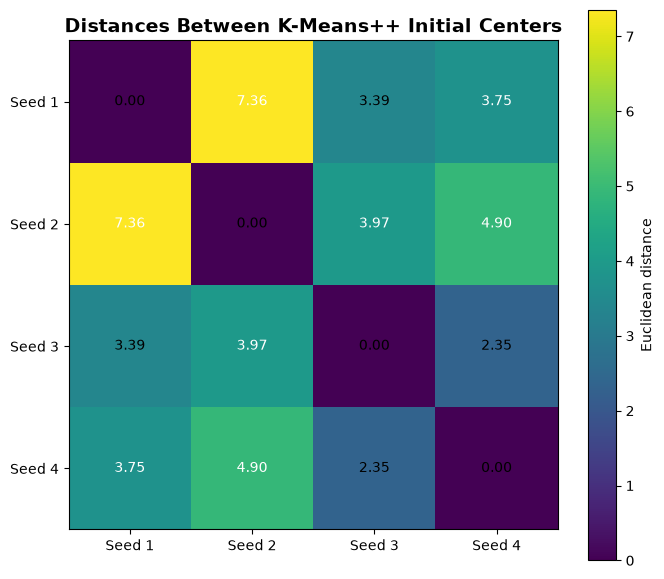

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

distance_image = ax.imshow(
    initial_distance_matrix,
    cmap="viridis",
)

ax.set_xticks(np.arange(N_CLUSTERS))
ax.set_yticks(np.arange(N_CLUSTERS))

ax.set_xticklabels(seed_labels)
ax.set_yticklabels(seed_labels)

ax.set_title(
    "Distances Between K-Means++ Initial Centers",
    fontsize=14,
    fontweight="bold",
)

# Add each distance value inside the matrix
for row_index in range(N_CLUSTERS):
    for column_index in range(N_CLUSTERS):
        distance_value = initial_distance_matrix[
            row_index,
            column_index,
        ]

        text_color = (
            "white"
            if distance_value > initial_distance_matrix.max() / 2
            else "black"
        )

        ax.text(
            column_index,
            row_index,
            f"{distance_value:.2f}",
            ha="center",
            va="center",
            color=text_color,
        )

colorbar = fig.colorbar(
    distance_image,
    ax=ax,
)

colorbar.set_label("Euclidean distance")

fig.tight_layout()

save_figure(fig, "seed_distances.png")

plt.show()

##### Explanation :
The diagonal cells contain zeros because every seed has zero distance from itself.

The off-diagonal cells show the distances between different selected centers. Darker or lighter regions correspond to smaller or larger values according to the color scale.

The matrix confirms that K-Means++ selected observations from separated regions rather than placing several centers inside the same local group.

The plot is saved as:
```
plots/kmeanspp_init/seed_distances.png
```

### Visualize the K-Means++ Initial Centers

This plot reproduces the main idea of the official scikit-learn K-Means++ example.

The small colored points show the generated observations. The larger blue X markers show the observations selected by K-Means++.

At this stage, K-Means has not updated the centers.

The plot is saved as `init_seeds.png`.

Figure saved to:
C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeanspp_init\init_seeds.png


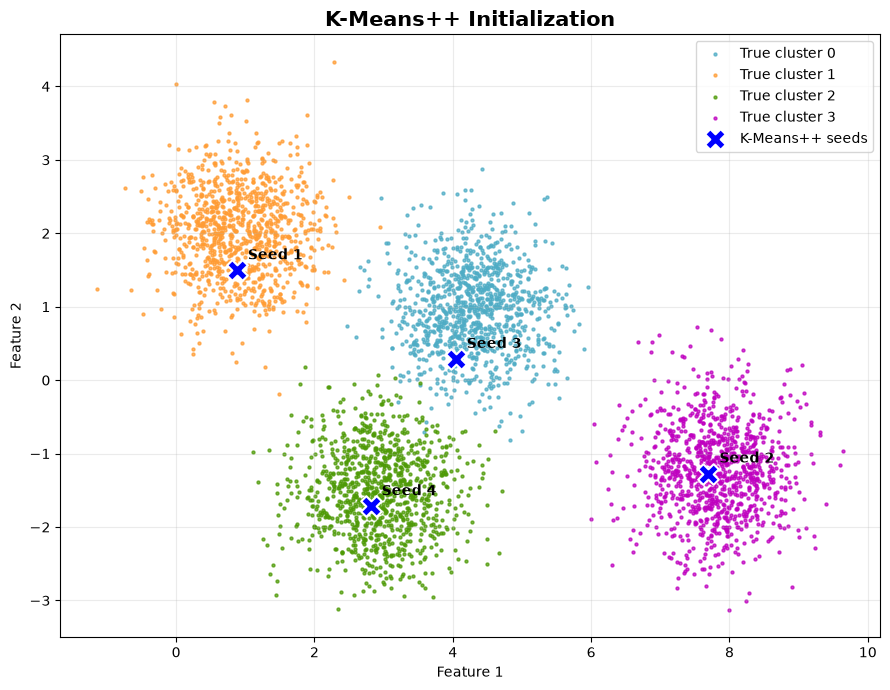

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))

# Plot the synthetic observations
for cluster_id, color in enumerate(CLUSTER_COLORS):
    cluster_mask = y_true == cluster_id

    ax.scatter(
        X[cluster_mask, 0],
        X[cluster_mask, 1],
        color=color,
        marker=".",
        s=18,
        alpha=0.75,
        label=f"True cluster {cluster_id}",
    )

# Plot the selected K-Means++ centers
ax.scatter(
    centers_init[:, 0],
    centers_init[:, 1],
    color="blue",
    marker="X",
    s=220,
    edgecolor="white",
    linewidth=1.5,
    label="K-Means++ seeds",
    zorder=5,
)

# Label each selected seed
for seed_number, center in enumerate(centers_init, start=1):
    ax.annotate(
        f"Seed {seed_number}",
        xy=(center[0], center[1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title(
    "K-Means++ Initialization",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

save_figure(fig, "init_seeds.png")

plt.show()

##### Explanation :
The large blue X markers should appear in four different data regions.

This demonstrates the purpose of K-Means++ initialization: to reduce the chance that several starting centers are placed inside the same natural cluster while another cluster remains unrepresented.

These are only the initial positions. They will move when K-Means recalculates each center using the observations assigned to it.

The plot is saved as:
```
plots/kmeanspp_init/init_seeds.png
```

### Fit K-Means Using the Selected Initial Centers

The initial centers returned by kmeans_plusplus() are passed directly to the KMeans estimator.

Because the centers have already been selected, n_init=1 is used. Running multiple initializations is unnecessary because the model is being instructed to use this exact set of starting centers.

The algorithm repeatedly:

Assigns each observation to its nearest center.
Recalculates each center as the mean of its assigned observations.
Continues until convergence or the maximum iteration limit is reached.

In [14]:
kmeans_model = KMeans(
    n_clusters=N_CLUSTERS,
    init=centers_init,
    n_init=1,
    max_iter=300,
    random_state=RANDOM_STATE,
    algorithm="lloyd",
)

# Measure fitting time
fit_start_time = perf_counter()

predicted_labels = kmeans_model.fit_predict(X)

fit_time_seconds = perf_counter() - fit_start_time

# Extract the final centers
final_centers = kmeans_model.cluster_centers_

print("=" * 80)
print("K-MEANS MODEL FIT")
print("=" * 80)
print(f"Fitting time       : {fit_time_seconds:.6f} seconds")
print(f"Iterations required: {kmeans_model.n_iter_}")
print(f"Final inertia      : {kmeans_model.inertia_:.4f}")
print("=" * 80)

K-MEANS MODEL FIT
Fitting time       : 1.321024 seconds
Iterations required: 3
Final inertia      : 2794.2414


##### Explanation :
In the original notebook execution, the model converged in approximately three iterations and produced an inertia near:
```
2794.2414
```
The small number of iterations indicates that the K-Means++ starting centers were already close to suitable final cluster locations.

The fitting time depends on the computer, operating system, processor load, Python version, and scikit-learn version. Therefore, the execution time may differ between runs.

### Calculate Clustering Evaluation Metrics

This section evaluates the fitted model using several complementary metrics.

##### Inertia

The sum of squared distances between observations and their assigned cluster centers. Lower values indicate more compact clusters when comparing models fitted to the same dataset.

##### Silhouette Score

Measures both within-cluster compactness and between-cluster separation. Values closer to 1 indicate stronger clustering.

##### Calinski-Harabasz Score

Compares between-cluster separation with within-cluster variation. Higher values generally indicate better-defined clusters.

##### Davies-Bouldin Index

Measures average similarity between clusters. Lower values indicate better separation.

##### Adjusted Rand Index

Compares predicted clusters with the known synthetic labels. A value of 1 indicates perfect agreement.

The complete metrics table is saved as `metrics.csv`.

In [15]:
silhouette = silhouette_score(
    X,
    predicted_labels,
)

calinski_harabasz = calinski_harabasz_score(
    X,
    predicted_labels,
)

davies_bouldin = davies_bouldin_score(
    X,
    predicted_labels,
)

adjusted_rand = adjusted_rand_score(
    y_true,
    predicted_labels,
)

metrics_df = pd.DataFrame(
    [
        {
            "Samples": X.shape[0],
            "Features": X.shape[1],
            "Clusters": N_CLUSTERS,
            "Inertia": kmeans_model.inertia_,
            "Silhouette": silhouette,
            "Calinski_Harabasz": calinski_harabasz,
            "Davies_Bouldin": davies_bouldin,
            "Adjusted_Rand": adjusted_rand,
            "Iterations": kmeans_model.n_iter_,
            "Fit_time_seconds": fit_time_seconds,
        }
    ]
)

# Create a rounded table for notebook display
metrics_display = metrics_df.copy()

numeric_columns = metrics_display.select_dtypes(
    include="number"
).columns

metrics_display[numeric_columns] = (
    metrics_display[numeric_columns]
    .round(4)
)

display(metrics_display.T)

# Save the full-precision metrics
metrics_path = RESULTS_DIR / "metrics.csv"

metrics_df.to_csv(
    metrics_path,
    index=False,
)

print(f"Clustering metrics saved to:\n{metrics_path}")

,0
Samples,4000.0000
Features,2.0000
Clusters,4.0000
Inertia,2794.2414
Silhouette,0.6750
Calinski_Harabasz,16329.9580
Davies_Bouldin,0.4533
Adjusted_Rand,0.9940
Iterations,3.0000
Fit_time_seconds,1.3210


Clustering metrics saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init\metrics.csv


##### Explanation :
The original notebook produced approximately:
|Metric|Result|
|:----:|:----:|
|Inertia|$2794.2414$|
|Silhouette Score|$0.6750$|
|Calinski-Harabasz Score|$16329.9580$|
|Davies-Bouldin Index|$0.4533$|
|Adjusted Rand Index|$0.9940$|
|Iterations|$3$|  

The results indicate excellent clustering performance:

A silhouette score near $0.675$ indicates compact and well-separated clusters.
The high Calinski-Harabasz score indicates strong separation relative to within-cluster variation.
The low Davies-Bouldin value indicates that the clusters are not highly similar to one another.
The Adjusted Rand Index near $0.994$ shows almost perfect agreement with the true synthetic groups.

The metrics are saved as:
```
results/kmeanspp_init/metrics.csv
```

### Examine the Predicted Cluster Sizes

Cluster-size analysis helps determine whether the fitted model produced balanced groups or created an extremely small cluster.

This section counts the observations assigned to each predicted cluster and calculates their percentages.

The table is saved as `cluster_sizes.csv`.

In [16]:
predicted_cluster_sizes_df = (
    pd.Series(predicted_labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Sample_count")
)

predicted_cluster_sizes_df["Percentage"] = (
    predicted_cluster_sizes_df["Sample_count"]
    / len(predicted_labels)
    * 100
).round(2)

display(predicted_cluster_sizes_df)

# Save the predicted cluster sizes
predicted_cluster_sizes_path = RESULTS_DIR / "cluster_sizes.csv"

predicted_cluster_sizes_df.to_csv(
    predicted_cluster_sizes_path,
    index=False,
)

print(
    "Predicted cluster sizes saved to:\n"
    f"{predicted_cluster_sizes_path}"
)

,Cluster,Sample_count,Percentage
0,0,998,24.95
1,1,1000,25.00
2,2,1000,25.00
3,3,1002,25.05


Predicted cluster sizes saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init\cluster_sizes.csv


##### Explanation :
The original notebook assigned approximately:

- $998$ observations to Cluster 0
- $1,000$ observations to Cluster 1
- $1,000$ observations to Cluster 2
- $1,002$ observations to Cluster 3

Each predicted cluster therefore represents approximately $25\%$ of the dataset.

The predicted distribution closely matches the true balanced distribution. No cluster is empty or unusually small.

The table is saved as:
```
results/kmeanspp_init/cluster_sizes.csv
```

### Compare Initial and Final Center Coordinates

K-Means++ selects starting observations, but these observations are not normally the final cluster means.

This section compares the initial center coordinates with the final K-Means centroid coordinates.

The Euclidean movement distance is calculated as:
$$
d = \sqrt{(x_f-x_i)^2 + (y_f-y_i)^2}
$$  

where :
- $x_i,y_i$ are the initial center coordinates
- $x_f,y_f$ are the final center coordinates

The result is saved as `center_movement.csv`.

In [17]:
center_movement = np.linalg.norm(
    final_centers - centers_init,
    axis=1,
)

centers_comparison_df = pd.DataFrame(
    {
        "Cluster": np.arange(N_CLUSTERS),
        "Initial_feature_1": centers_init[:, 0],
        "Initial_feature_2": centers_init[:, 1],
        "Final_feature_1": final_centers[:, 0],
        "Final_feature_2": final_centers[:, 1],
        "Movement_distance": center_movement,
    }
)

# Create a rounded table for notebook display
centers_comparison_display = centers_comparison_df.copy()

coordinate_columns = [
    "Initial_feature_1",
    "Initial_feature_2",
    "Final_feature_1",
    "Final_feature_2",
    "Movement_distance",
]

centers_comparison_display[coordinate_columns] = (
    centers_comparison_display[coordinate_columns]
    .round(4)
)

display(centers_comparison_display)

# Save the complete center comparison
centers_comparison_path = RESULTS_DIR / "center_movement.csv"

centers_comparison_df.to_csv(
    centers_comparison_path,
    index=False,
)

print(
    "Initial and final center comparison saved to:\n"
    f"{centers_comparison_path}"
)

,Cluster,Initial_feature_1,Initial_feature_2,Final_feature_1,Final_feature_2,Movement_distance
0,0,0.8770,1.4953,0.8981,2.0181,0.5233
1,1,7.6942,-1.2730,7.8153,-1.2380,0.1261
2,2,4.0411,0.2878,4.2948,0.9618,0.7202
3,3,2.8111,-1.7173,2.9177,-1.5238,0.2209


Initial and final center comparison saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init\center_movement.csv


##### Explanation :
The centers moved because K-Means++ selected individual observations, while the final K-Means centers represent the mean locations of complete groups.

The movement distances are relatively small compared with the distances between the initial seeds. This indicates that K-Means++ placed the initial centers near appropriate cluster regions.

The comparison is saved as:
```
results/kmeanspp_init/center_movement.csv
```

### Visualize the Final K-Means Clusters

This plot colors observations according to their predicted K-Means cluster.

The markers represent:

- White X markers: original K-Means++ initial centers
- Black star markers: final K-Means centroids

The plot is saved as `final_clusters.png`.

Figure saved to:
C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeanspp_init\final_clusters.png


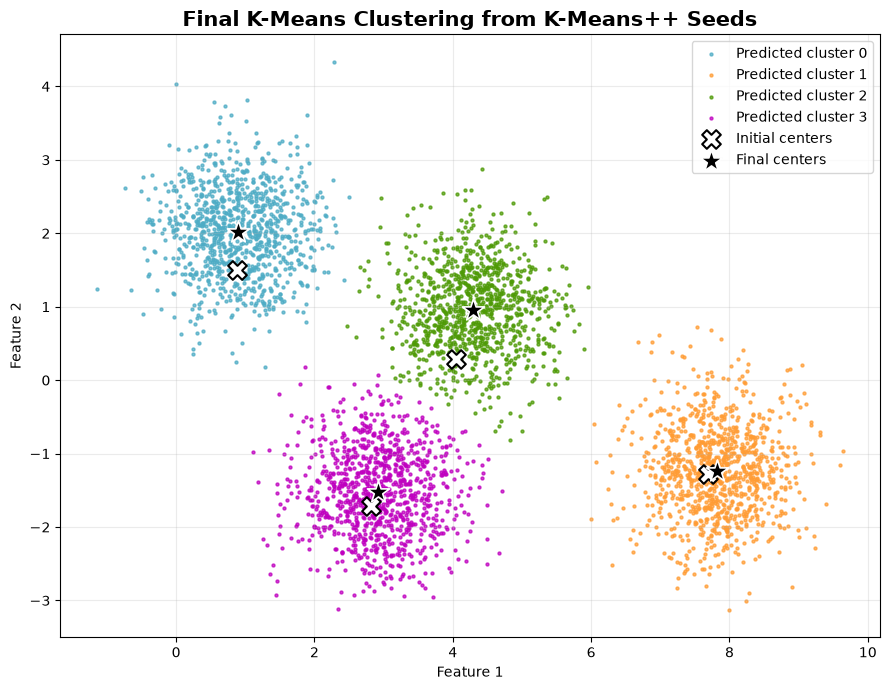

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))

# Plot observations using predicted cluster labels
for cluster_id, color in enumerate(CLUSTER_COLORS):
    cluster_mask = predicted_labels == cluster_id

    ax.scatter(
        X[cluster_mask, 0],
        X[cluster_mask, 1],
        color=color,
        marker=".",
        s=18,
        alpha=0.75,
        label=f"Predicted cluster {cluster_id}",
    )

# Plot the initial K-Means++ centers
ax.scatter(
    centers_init[:, 0],
    centers_init[:, 1],
    color="white",
    marker="X",
    s=180,
    edgecolor="black",
    linewidth=1.5,
    label="Initial centers",
    zorder=5,
)

# Plot the final K-Means centers
ax.scatter(
    final_centers[:, 0],
    final_centers[:, 1],
    color="black",
    marker="*",
    s=280,
    edgecolor="white",
    linewidth=1.2,
    label="Final centers",
    zorder=6,
)

ax.set_title(
    "Final K-Means Clustering from K-Means++ Seeds",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

save_figure(fig, "final_clusters.png")

plt.show()

##### Explanation :
The predicted clusters should closely follow the four visible Gaussian groups.

The final black stars should appear near the central location of each cluster. The initial white X markers may be slightly away from the final centroids because they represent individual selected observations rather than cluster means.

The strong agreement between the visible groups and the predicted assignments supports the high Adjusted Rand Index obtained earlier.

The plot is saved as:
```
plots/kmeanspp_init/final_clusters.png
```

### Visualize Initial-to-Final Center Movement

This visualization uses arrows to show how each K-Means++ initial center moved during K-Means optimization.

For every cluster:

- The X marker represents the initial center.
- The star marker represents the final centroid.
- The arrow shows the direction of movement.
- The annotation reports the movement distance.

The plot is saved as `center_movement.png`.

Figure saved to:
C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeanspp_init\center_movement.png


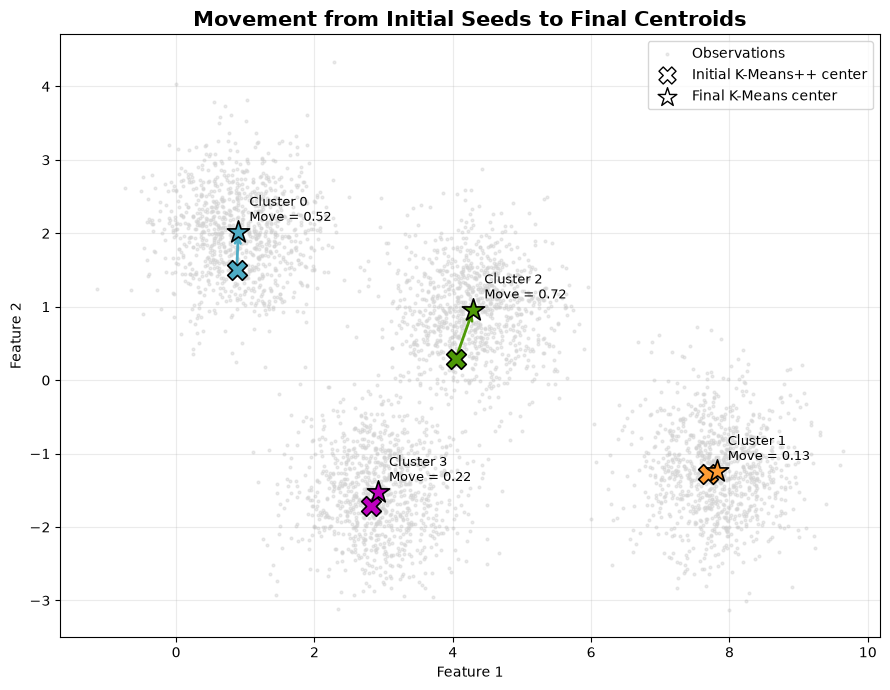

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))

# Plot all observations in the background
ax.scatter(
    X[:, 0],
    X[:, 1],
    color="lightgray",
    marker=".",
    s=15,
    alpha=0.45,
    label="Observations",
)

for cluster_id in range(N_CLUSTERS):
    initial_center = centers_init[cluster_id]
    final_center = final_centers[cluster_id]
    cluster_color = CLUSTER_COLORS[cluster_id]

    # Plot initial center
    ax.scatter(
        initial_center[0],
        initial_center[1],
        color=cluster_color,
        marker="X",
        s=200,
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    # Plot final center
    ax.scatter(
        final_center[0],
        final_center[1],
        color=cluster_color,
        marker="*",
        s=280,
        edgecolor="black",
        linewidth=1.2,
        zorder=6,
    )

    # Draw movement arrow
    ax.annotate(
        "",
        xy=(final_center[0], final_center[1]),
        xytext=(initial_center[0], initial_center[1]),
        arrowprops={
            "arrowstyle": "->",
            "linewidth": 2,
            "color": cluster_color,
        },
    )

    # Add movement annotation
    ax.annotate(
        (
            f"Cluster {cluster_id}\n"
            f"Move = {center_movement[cluster_id]:.2f}"
        ),
        xy=(final_center[0], final_center[1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
    )

# Create representative legend entries
ax.scatter(
    [],
    [],
    color="white",
    marker="X",
    s=150,
    edgecolor="black",
    label="Initial K-Means++ center",
)

ax.scatter(
    [],
    [],
    color="white",
    marker="*",
    s=200,
    edgecolor="black",
    label="Final K-Means center",
)

ax.set_title(
    "Movement from Initial Seeds to Final Centroids",
    fontsize=15,
    fontweight="bold",
)

ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()

save_figure(fig, "center_movement.png")

plt.show()

##### Explanation :
The arrows show that K-Means++ only determines the starting positions.

After initialization, standard K-Means moves each center toward the mean position of the observations assigned to that cluster.

Short arrows indicate that the selected starting observations were already close to the final cluster centroids. The movement is expected because a selected observation is unlikely to be positioned exactly at the arithmetic mean of a complete cluster.

The plot is saved as:
```
plots/kmeanspp_init/center_movement.png
```

### Create a Human-Readable Run Summary

This section combines the most important experiment settings, initialization results, clustering metrics, center movements, and output locations into a text summary.

The summary is saved as `run_summary.txt`.

In [20]:
summary_lines = [
    "K-MEANS++ INITIALIZATION TUTORIAL",
    "=" * 60,
    "",
    "DATASET",
    f"Number of samples: {X.shape[0]:,}",
    f"Number of features: {X.shape[1]}",
    f"Number of clusters: {N_CLUSTERS}",
    f"Cluster standard deviation: {CLUSTER_STD}",
    f"Random state: {RANDOM_STATE}",
    "",
    "K-MEANS++ INITIALIZATION",
    f"Selected sample indices: {selected_indices.tolist()}",
    f"Minimum seed distance: {upper_triangle.min():.6f}",
    f"Mean seed distance: {upper_triangle.mean():.6f}",
    f"Maximum seed distance: {upper_triangle.max():.6f}",
    "",
    "FINAL K-MEANS MODEL",
    f"Inertia: {kmeans_model.inertia_:.6f}",
    f"Silhouette score: {silhouette:.6f}",
    f"Calinski-Harabasz score: {calinski_harabasz:.6f}",
    f"Davies-Bouldin index: {davies_bouldin:.6f}",
    f"Adjusted Rand Index: {adjusted_rand:.6f}",
    f"Iterations: {kmeans_model.n_iter_}",
    f"Fit time in seconds: {fit_time_seconds:.6f}",
    "",
    "CENTER MOVEMENT",
]

# Add one movement line for each cluster
for cluster_id, movement in enumerate(center_movement):
    summary_lines.append(
        f"Cluster {cluster_id}: {movement:.6f}"
    )

summary_lines.extend(
    [
        "",
        "OUTPUT FOLDERS",
        f"Plots: {PLOTS_DIR}",
        f"Results: {RESULTS_DIR}",
    ]
)

# Combine all lines into one text block
run_summary = "\n".join(summary_lines)

print(run_summary)

# Save the summary
run_summary_path = RESULTS_DIR / "run_summary.txt"

run_summary_path.write_text(
    run_summary,
    encoding="utf-8",
)

print(f"\nRun summary saved to:\n{run_summary_path}")

K-MEANS++ INITIALIZATION TUTORIAL

DATASET
Number of samples: 4,000
Number of features: 2
Number of clusters: 4
Cluster standard deviation: 0.6
Random state: 0

K-MEANS++ INITIALIZATION
Selected sample indices: [2195, 2161, 1757, 1589]
Minimum seed distance: 2.352288
Mean seed distance: 4.287084
Maximum seed distance: 7.357839

FINAL K-MEANS MODEL
Inertia: 2794.241383
Silhouette score: 0.674975
Calinski-Harabasz score: 16329.957974
Davies-Bouldin index: 0.453291
Adjusted Rand Index: 0.994013
Iterations: 3
Fit time in seconds: 1.321024

CENTER MOVEMENT
Cluster 0: 0.523264
Cluster 1: 0.126088
Cluster 2: 0.720202
Cluster 3: 0.220907

OUTPUT FOLDERS
Plots: C:\Users\samsa\Documents\Capstone Project\Project\plots\kmeanspp_init
Results: C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init

Run summary saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\kmeanspp_init\run_summary.txt


##### Explanation :
The text output provides a concise record of the complete experiment.

It includes:

- Dataset size and configuration
- Selected initial sample indices
- Minimum, mean, and maximum seed distances
- Final clustering metrics
- Number of optimization iterations
- Model-fitting time
- Movement distance of every center
- Plot and result folder locations

This file is useful for quickly reviewing the experiment without reopening every CSV file.

The summary is saved as:
```
results/kmeanspp_init/run_summary.txt
```

### Display All Saved Output Files

This final verification step lists all files currently present in the K-Means++ plot and result folders.

It confirms that the expected outputs were successfully created.

In [21]:
saved_plot_files = sorted(
    file_path.name
    for file_path in PLOTS_DIR.glob("*")
    if file_path.is_file()
)

saved_result_files = sorted(
    file_path.name
    for file_path in RESULTS_DIR.glob("*")
    if file_path.is_file()
)

print("=" * 80)
print("SAVED PLOTS")
print("=" * 80)

for filename in saved_plot_files:
    print(f"- {filename}")

print("\n" + "=" * 80)
print("SAVED RESULTS")
print("=" * 80)

for filename in saved_result_files:
    print(f"- {filename}")

print("\n" + "=" * 80)
print("NOTEBOOK EXECUTION COMPLETED")
print("=" * 80)

SAVED PLOTS
- center_movement.png
- data_blobs.png
- final_clusters.png
- init_seeds.png
- seed_distances.png

SAVED RESULTS
- center_movement.csv
- cluster_sizes.csv
- data_summary.csv
- init_centers.csv
- metrics.csv
- run_summary.txt
- seed_distances.csv
- true_sizes.csv

NOTEBOOK EXECUTION COMPLETED


##### Explanation :
After successful execution, the plot folder should contain:
```
center_movement.png
data_blobs.png
final_clusters.png
init_seeds.png
seed_distances.png
```
The result folder should contain:
```
center_movement.csv
cluster_sizes.csv
data_summary.csv
init_centers.csv
metrics.csv
run_summary.txt
seed_distances.csv
true_sizes.csv
```
The final completion message confirms that all notebook sections have executed.

### Final Interpretation of the Results

K-Means++ selected four observations from different regions of the feature space. The pairwise-distance matrix confirmed that the selected initial centers were not concentrated in one small area.

The initial centers were then supplied directly to the K-Means model. During model fitting, each center moved from the selected observation toward the mean location of its assigned observations.

The model converged in only a few iterations, demonstrating that the K-Means++ initialization provided suitable starting positions.

For this synthetic dataset:

- The clusters are compact.
- The clusters are approximately spherical.
- The cluster sizes are balanced.
- The groups are clearly separated.
- The silhouette score is relatively high.
- The Davies-Bouldin index is relatively low.
- The Adjusted Rand Index is close to 1.
- The predicted cluster sizes closely match the true cluster sizes.

These results demonstrate why initialization is important in K-Means. Poor starting centers can cause several centroids to begin in the same data region, leaving another region unrepresented. K-Means++ reduces this risk by favoring new centers that are farther away from centers that have already been selected.